In [1]:
import torch
import torch.nn as nn
import numpy as np
from scipy.sparse import linalg
from scipy.stats import ortho_group

from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.autograd.functional import jacobian
from torch.utils.data import TensorDataset, DataLoader

from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

Using device: cuda


In [2]:
def make_functional_model(model):
    param_shapes = [(name, param.shape, param.numel()) for name, param in model.named_parameters()]
    
    def functional_model(params,x):
        param_dict = {}
        start_idx = 0
        for name,shape,size in param_shapes:
            param_dict[name] = params[start_idx:start_idx+size].view(shape)
            start_idx += size
        return torch.func.functional_call(model, param_dict, x)
    
    return functional_model

In [13]:
@torch.no_grad()
def pinv(M: torch.Tensor, k: int = 2, tol: float = 1e-10, rtol:float = 1e-3, full=False, randomized=False) -> torch.Tensor:
    with torch.no_grad():
        M = M.detach()
        if full:
            U, S, Vh = truncated_svd_full(M,k=k,rtol=rtol)
        elif randomized:
            U, S, Vh = randomized_SVD(M, k=k, rtol=rtol)
        else:
            U, S, Vh = truncated_svd(M, k=k, rtol=rtol)
        S_inv = torch.where(S > tol, 1.0 / S, torch.zeros_like(S))
        result = Vh.T @ S_inv.diag() @ U.T
    return result.detach()

@torch.no_grad()
def truncated_svd(A: torch.Tensor, k: int = 2, rtol:float=1e-3) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    with torch.no_grad():
        A = A.detach()
        m, n = A.shape
        if n <= m:
            C = A.T @ A       # (n x n), symmetric PSD
            # Use LOBPCG or plain eigen; eigsh-style not yet standard in torch
            # torch.lobpcg expects symmetric; give random init
            #X = torch.randn(n, k, device=A.device, dtype=A.dtype)
            evals, evecs = torch.lobpcg(C, k=k, largest=True)  # top-k
            s = evals.clamp_min(0).sqrt()
            V = evecs
            # Left sing vecs: U = A V / s
            U = (A @ V) / s.clamp_min(torch.finfo(A.dtype).eps)
            Vh = V.T
            s = torch.where(s > rtol * s[0], s, torch.zeros_like(s))
            return U.detach(), s.detach(), Vh.detach()
            #Av = A @ evecs
            #u,s,vh = torch.linalg.svd(Av, full_matrices=False)
        else:
            C = A @ A.T       # (m x m)
            #X = torch.randn(m, k, device=A.device, dtype=A.dtype)
            evals, evecs = torch.lobpcg(C, k=k, largest=True)
            s = evals.clamp_min(0).sqrt()
            U = evecs
            Vh = ((U.T @ A) / s.clamp_min(torch.finfo(A.dtype).eps).reshape(-1,1)).conj()
            s = torch.where(s > rtol * s[0], s, torch.zeros_like(s))
            return U.detach(), s.detach(), Vh.detach()

@torch.compile
@torch.no_grad()     
def truncated_svd_full(A: torch.Tensor, k: int = 2, rtol:float=1e-3) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    with torch.no_grad():
        A = A.detach()
        U, S, Vh = torch.linalg.svd(A, full_matrices=True)
        U = U[:,:k]
        S = S[:k]
        Vh = Vh[:k,:]
        S = torch.where(S > rtol * S[0], S, torch.zeros_like(S))
        return U.detach(), S.detach(), Vh.detach()

@torch.compile
@torch.no_grad()
def randomized_SVD(A, k, p=10, q=0, rtol:float=1e-3):
    m,n = A.shape
    r = k+p
    device = A.device
    dtype = A.dtype

    Omega = torch.randn(n, r, device=device, dtype=dtype)
    Y = A @ Omega
    for _ in range(q):
        Y = A @ (A.T @ Y)
    Q, _ = torch.linalg.qr(Y)
    B = Q.T @ A
    Ub,S,Vh = torch.linalg.svd(B, full_matrices=False)
    U = Q @ Ub

    U = U[:,:k]
    S = S[:k]
    Vh = Vh[:k,:]
    S = torch.where(S > rtol * S[0], S, torch.zeros_like(S))
    return U, S, Vh
    

# Define a model

In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, activation=nn.SiLU):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dims[0]), activation()]
        for i in range(1,len(hidden_dims)):
            layers.append(nn.Linear(hidden_dims[i-1], hidden_dims[i]))
            layers.append(activation())
        layers.append(nn.Linear(hidden_dims[-1], output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [9]:
def func(x):
    return torch.exp(-10*x**2)*torch.sin(2*x)

xtrain = 2*torch.rand(10_000,1) - 1 # U[-1,1]
ytrain = func(xtrain)
mean, std = ytrain.mean(), ytrain.std()
ytrain = (ytrain - mean) / std

xval = 2*torch.rand(10_000,1) - 1
yval = func(xval)
yval = (yval - mean) / std

xtest = torch.linspace(-1,1,1000).unsqueeze(1)
ytest = func(xtest)
ytest = (ytest - mean) / std

train_dataset = TensorDataset(xtrain, ytrain)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_dataset = TensorDataset(xval, yval)
val_loader = DataLoader(val_dataset, batch_size=10_000, shuffle=False)
test_dataset = TensorDataset(xtest, ytest)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

In [10]:
model = MLP(input_dim=1, hidden_dims=[16,16], output_dim=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
num_epochs = 1000
losses = defaultdict(list)
for epoch in tqdm(range(num_epochs)):
    epoch_losses = defaultdict(list)
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        ypred = model(xb)
        loss = loss_fn(ypred, yb)
        loss.backward()
        optimizer.step()
        epoch_losses['train'].append(loss.item())
    model.eval()
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            ypred = model(xb)
            loss = loss_fn(ypred, yb)
            epoch_losses['val'].append(loss.item())
    for k,v in epoch_losses.items():
        losses[k].append(np.mean(v))

100%|██████████| 1000/1000 [02:57<00:00,  5.64it/s]


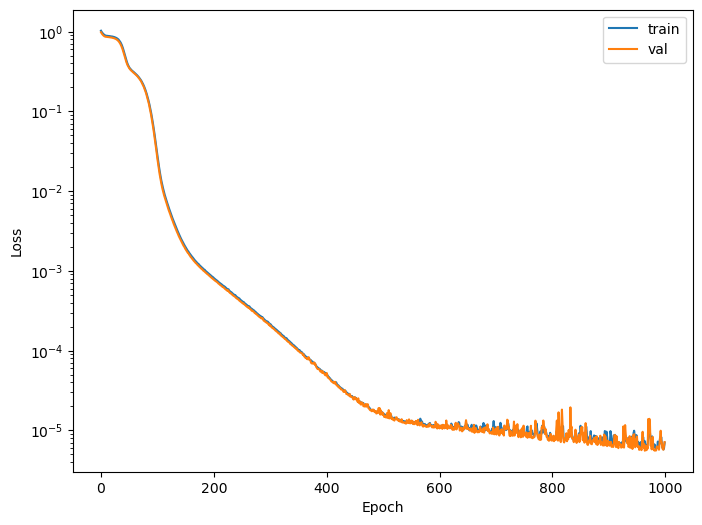

In [11]:
plt.figure(figsize=(8,6))
plt.plot(losses['train'], label='train')
plt.plot(losses['val'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

## try truncated svd descent

In [14]:
def get_jacobian(params, func_model, batch):
    x, y = batch  # x has shape (B, d), y shape (B,1) for 1D regression
    # Ensure parameters don't require gradients for Jacobian computation
    params = params.detach()
    x = x.detach()
    
    with torch.no_grad():
        # Use torch.func.jacrev for better performance and no gradient tracking
        jac = torch.func.jacrev(lambda p: func_model(p, x).squeeze())(params)  # (B, P)
    return jac.detach()

def delta_f(params, func_model, batch):
    x, y = batch
    with torch.no_grad():
        y_pred = func_model(params.detach(), x.detach())
    return (y_pred - y).detach(), y_pred.detach()

@torch.compile
def train_step_svd_sgd(params, func_model, batch, lr, k, rtol=1e-3):
    # Ensure everything is detached from the start
    params = params.detach()
    x, y = batch
    x, y = x.detach(), y.detach()
    batch = (x, y)
    
    with torch.no_grad():
        J = get_jacobian(params, func_model, batch)
        b, preds = delta_f(params, func_model, batch)
        pseudo_inv = pinv(J, k=k, randomized=True,rtol=rtol)
        delta_p = (pseudo_inv @ b).squeeze()
        new_params = params - lr * delta_p
    
    return new_params.detach(), preds.detach()

In [31]:
model_svd = MLP(input_dim=1, hidden_dims=[16,16], output_dim=1).to(device)
params_svd = parameters_to_vector(model_svd.parameters()).detach()
model_svd.eval()

# Turn off gradient computation for the model completely
for param in model_svd.parameters():
    param.requires_grad_(False)

func_model_svd = make_functional_model(model_svd)

lr_svd = 0.1
k_svd = 10
rtol = 1e-3

loss_fn = nn.MSELoss()
num_epochs = 250
batch_size = 80
losses_svd = defaultdict(list)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=10_000, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Ensure all computations are done without gradients
with torch.no_grad():
    for epoch in tqdm(range(num_epochs)):
        epoch_losses = defaultdict(list)
        for xb, yb in train_loader:
            xb, yb = xb.to(device).detach(), yb.to(device).detach()
            batch = (xb, yb)
            params_svd, ypred = train_step_svd_sgd(params_svd, func_model_svd, batch, lr=lr_svd, k=k_svd, rtol=rtol)
            loss = loss_fn(ypred, yb)
            epoch_losses['train'].append(loss.item())
        
        for xb, yb in val_loader:
            xb, yb = xb.to(device).detach(), yb.to(device).detach()
            ypred = func_model_svd(params_svd, xb)
            loss = loss_fn(ypred, yb)
            epoch_losses['val'].append(loss.item())
        
        for k_name, v in epoch_losses.items():
            losses_svd[k_name].append(np.mean(v))

100%|██████████| 250/250 [01:31<00:00,  2.72it/s]


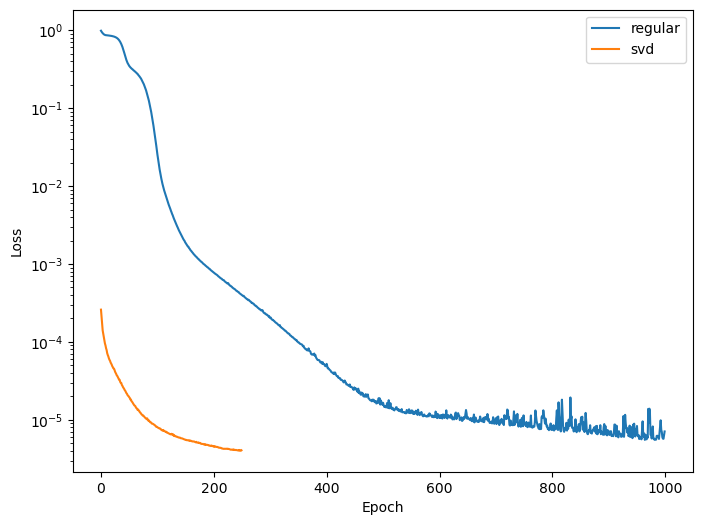

In [32]:
plt.figure(figsize=(8,6))
plt.plot(losses['val'], label='regular')
plt.plot(losses_svd['val'], label='svd')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()